In [1]:
import os
import pandas as pd
from PIL import Image
import numpy as np

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from neuralop.models import FNO

import torch
import torch.nn as nn
import torch.fft as fft
import math

In [2]:
def make_fourier_pos_features(H, W, num_freqs=4, device="cpu"):
    ys = torch.linspace(-1, 1, H, device=device)
    xs = torch.linspace(-1, 1, W, device=device)
    yy, xx = torch.meshgrid(ys, xs, indexing="ij")  # (H,W)

    feats = [xx, yy]
    for k in range(1, num_freqs + 1):
        feats.append(torch.sin(k * math.pi * xx))
        feats.append(torch.cos(k * math.pi * xx))
        feats.append(torch.sin(k * math.pi * yy))
        feats.append(torch.cos(k * math.pi * yy))
    grid = torch.stack(feats, dim=0)  # (C_pos, H, W)
    return grid

In [3]:
from skimage.color import rgb2gray
from skimage.filters import sobel

In [3]:
def compute_edge_weights_for_image(img_path, alpha=1.0):
    """
    img_path: path to GT PNG
    returns: weight map [H,W] in [1, 1+alpha] as float32
    """
    img = imageio.imread(img_path)  # H x W x 3, uint8
    img = img.astype(np.float32) / 255.0

    if img.ndim == 3 and img.shape[2] == 4:
        img = img[..., :3]  # take RGB

    gray = rgb2gray(img)  # [H,W] in [0,1]


    # Sobel gradient magnitude
    mag = sobel(gray).astype(np.float32)  # [H,W]

    # Normalize to [0,1]
    mag_min = mag.min()
    mag_max = mag.max()
    norm = (mag - mag_min) / (mag_max - mag_min + 1e-6)

    # Convert to weight map in [1, 1+alpha]
    weight = 1.0 + alpha * norm
    return weight.astype(np.float32)

In [4]:
class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, 3, padding=1)
        self.conv2 = nn.Conv2d(ch, ch, 3, padding=1)
        self.act = nn.GELU()

    def forward(self, x):
        y = self.act(self.conv1(x))
        y = self.conv2(y)
        return x + y   # residual

In [5]:
class ImageRefiner(nn.Module):
    def __init__(self, in_ch=3, hidden=32, num_blocks=3):
        super().__init__()
        self.entry = nn.Conv2d(in_ch, hidden, 3, padding=1)
        self.blocks = nn.Sequential(*[ResBlock(hidden) for _ in range(num_blocks)])
        self.exit  = nn.Conv2d(hidden, in_ch, 3, padding=1)

    def forward(self, x):
        # x: coarse RGB [B,3,H,W]
        h = self.entry(x)
        h = self.blocks(h)
        y = self.exit(h)
        out = x + y
        return torch.sigmoid(out)

In [6]:
class FNOPlusResNet(nn.Module):
    def __init__(self, latent_dim, img_size=(64,64)):
        super().__init__()
        H, W = img_size
        self.H, self.W = H, W
        self.latent_dim = latent_dim

        # 2D positional encodings (sin/cos x,y)
        self.register_buffer(
            "pos_features",
            make_fourier_pos_features(H, W, num_freqs=4)
        )
        C_pos = self.pos_features.shape[0]

        in_channels = latent_dim + C_pos
        self.input_proj = nn.Conv2d(in_channels, 64, 1)

        # FNO backbone from library
        self.fno = FNO(      # from neuraloperator or FNO2d variant
            n_modes=(40,40),
            hidden_channels=64,
            in_channels=64,
            out_channels=3
        )

        # Residual CNN refiner in image space
        self.refiner = ImageRefiner(in_ch=3, hidden=32)

    def forward(self, params):
        B, D = params.shape
        device = params.device

        z_grid = params.view(B, D, 1, 1).expand(B, D, self.H, self.W)
        pos = self.pos_features.to(device).unsqueeze(0).expand(B, -1, -1, -1)

        field = torch.cat([z_grid, pos], dim=1)
        x = self.input_proj(field)

        coarse = self.fno(x)        # [B,3,H,W], coarse prediction
        out = self.refiner(coarse)  # residual CNN, sharpen/high-freq
        return out

In [7]:
import pandas as pd
import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset
from torchvision import transforms

class BentPlaneDataset(Dataset):
    """
    Each sample:
      - input: [p1, p2, metallic, roughness, sin(phi), cos(phi),
                sin(theta), cos(theta), radius]
      - target: rendered RGB image (H,W)
    """
    def __init__(self, csv_path, img_size=(64, 64), normalize_params=True):
        self.df = pd.read_csv(csv_path)
        self.img_size = img_size
        self.normalize_params = normalize_params

        self.transform = transforms.Compose([
            transforms.Resize(img_size),
            transforms.ToTensor(),   # [0,1]
        ])

        if normalize_params:
            # Compute stats over scalar columns used in param vector

            vals = np.stack([
                self.df["p1"].values.astype(np.float32),
                self.df["p2"].values.astype(np.float32),
                self.df["metallic"].values.astype(np.float32),
                self.df["roughness"].values.astype(np.float32),
            ], axis=1)  # shape [N,9]

            self.param_mean = vals.mean(axis=0)
            self.param_std  = vals.std(axis=0) + 1e-6
        else:
            self.param_mean = None
            self.param_std  = None

    def __len__(self):
        return len(self.df)

    def _build_param_vector(self, row):

        scalars_np = np.array([
            float(row["p1"]),
            float(row["p2"]),
            float(row["metallic"]),
            float(row["roughness"]),
        ], dtype=np.float32)  # [4]

        if self.normalize_params:
            scalars_np = (scalars_np - self.param_mean) / self.param_std

        return torch.from_numpy(scalars_np)  # [9]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load image
        img = Image.open(row["image_path"]).convert("RGB")
        img = self.transform(img)  # [3,H,W] in [0,1]

        # Build conditioning vector
        param_vec = self._build_param_vector(row)  # [latent_dim=9]

        return param_vec, img

In [29]:
class BentPlaneDatasetWithEdges(Dataset):
    """
    Each sample:
      - param_vec: [p1, p2, metallic, roughness] (normalized)
      - image: [3,H,W] in [0,1]
      - edge_w: [1,H,W] in [1, 1+ALPHA]
    """
    def __init__(self, csv_path, img_size=(64, 64), normalize_params=True):
        self.df = pd.read_csv(csv_path)
        self.img_size = img_size
        self.normalize_params = normalize_params

        self.transform = transforms.Compose([
            transforms.Resize(img_size),
            transforms.ToTensor(),   # [0,1]
        ])

        # collect param values for normalization
        vals = np.stack([
            self.df["p1"].values.astype(np.float32),
            self.df["p2"].values.astype(np.float32),
            self.df["metallic"].values.astype(np.float32),
            self.df["roughness"].values.astype(np.float32),
        ], axis=1)   # [N,4]

        if normalize_params:
            self.param_mean = vals.mean(axis=0)
            self.param_std  = vals.std(axis=0) + 1e-6
        else:
            self.param_mean = None
            self.param_std  = None

    def __len__(self):
        return len(self.df)

    def _build_param_vector(self, row):
        scalars_np = np.array([
            float(row["p1"]),
            float(row["p2"]),
            float(row["metallic"]),
            float(row["roughness"]),
        ], dtype=np.float32)

        if self.normalize_params:
            scalars_np = (scalars_np - self.param_mean) / self.param_std

        return torch.from_numpy(scalars_np)  # [4]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # image
        img = Image.open(row["image_path"]).convert("RGB")
        img = self.transform(img)  # [3,H,W]

        # params
        param_vec = self._build_param_vector(row)  # [4]

        # edge weights
        edge_path = Path(row["edge_path"])
        w_np = np.load(edge_path).astype(np.float32)  # [H0,W0]

        # resize weight map to match img_size (if needed)
        w_img = Image.fromarray(w_np)
        w_img = w_img.resize(self.img_size, resample=Image.BILINEAR)
        w = torch.from_numpy(np.array(w_img, dtype=np.float32))  # [H,W]
        w = w.unsqueeze(0)  # [1,H,W]

        return param_vec, img, w

In [79]:
csv_path_train = "./plane_dataset_large/renders_darker/metadata_images_all.csv"
csv_path = "./plane_dataset_gt_20/renders/metadata_images_all.csv"


In [10]:
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FNOPlusResNet(    # whatever your current FNO+refiner class is called
    latent_dim=latent_dim,
    img_size=(128, 128),
).to(device)

loader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=2)

/home/yuanxiuw/miniconda3/lib/python3.13/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [15]:
df = pd.read_csv(csv_path)
len(df)

600

In [35]:
from pathlib import Path
import pandas as pd

base_dir   = Path("./plane_dataset_large")        # or bernstein_dataset_large
render_dir = base_dir / "renders_darker"          # change to your render dir
csv_path   = render_dir / "metadata_images_all.csv"
edge_dir   = render_dir / "edge_weights"

df = pd.read_csv(csv_path)

def edge_path_for_row(row):
    img_path = Path(row["image_path"])
    edge_name = img_path.stem + "_edge.npy"
    return str(edge_dir / edge_name)

df["edge_path"] = df.apply(edge_path_for_row, axis=1)
df.head()

,image_path,sample_id,coeff_path,mesh_path,hue,metallic,roughness,specular,material_type,base_color_r,base_color_g,base_color_b,phi,theta,radius,p1,p2,edge_path
0,/orcd/home/002/yuanxiuw/FNO_train/plane_datase...,1,/orcd/home/002/yuanxiuw/FNO_train/plane_datase...,/orcd/home/002/yuanxiuw/FNO_train/plane_datase...,0.0,0.0,0.1,0.5,plastic,0.4,0.08,0.08,1.570796,0.785398,1.5,-1.0,-1.0,plane_dataset_large/renders_darker/edge_weight...
1,/orcd/home/002/yuanxiuw/FNO_train/plane_datase...,1,/orcd/home/002/yuanxiuw/FNO_train/plane_datase...,/orcd/home/002/yuanxiuw/FNO_train/plane_datase...,0.0,0.0,0.5,0.5,plastic,0.4,0.08,0.08,1.570796,0.785398,1.5,-1.0,-1.0,plane_dataset_large/renders_darker/edge_weight...
2,/orcd/home/002/yuanxiuw/FNO_train/plane_datase...,1,/orcd/home/002/yuanxiuw/FNO_train/plane_datase...,/orcd/home/002/yuanxiuw/FNO_train/plane_datase...,0.0,0.0,0.9,0.5,plastic,0.4,0.08,0.08,1.570796,0.785398,1.5,-1.0,-1.0,plane_dataset_large/renders_darker/edge_weight...
3,/orcd/home/002/yuanxiuw/FNO_train/plane_datase...,1,/orcd/home/002/yuanxiuw/FNO_train/plane_datase...,/orcd/home/002/yuanxiuw/FNO_train/plane_datase...,0.0,1.0,0.1,0.5,metal,0.4,0.08,0.08,1.570796,0.785398,1.5,-1.0,-1.0,plane_dataset_large/renders_darker/edge_weight...
4,/orcd/home/002/yuanxiuw/FNO_train/plane_datase...,1,/orcd/home/002/yuanxiuw/FNO_train/plane_datase...,/orcd/home/002/yuanxiuw/FNO_train/plane_datase...,0.0,1.0,0.5,0.5,metal,0.4,0.08,0.08,1.570796,0.785398,1.5,-1.0,-1.0,plane_dataset_large/renders_darker/edge_weight...


In [37]:
df.to_csv(csv_path, index=False)
print("Updated CSV with edge_path column:", csv_path)

Updated CSV with edge_path column: plane_dataset_large/renders_darker/metadata_images_all.csv


In [61]:
from pathlib import Path
import imageio.v2 as imageio
dataset = BentPlaneDataset(csv_path, img_size=(128, 128))
param_vec_example, img_example= dataset[0]
latent_dim = param_vec_example.shape[0]
print("latent_dim:", latent_dim)
loader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=2)

latent_dim: 4


In [69]:
for idx, row in df.iterrows():
    img_path = Path(row["image_path"])
    if not img_path.is_file():
        print("Missing image:", img_path)
        continue

    edge_name = img_path.stem + "_edge.npy"
    edge_path = edge_dir / edge_name
    

    if edge_path.is_file():
        continue  # already done

    w = compute_edge_weights_for_image(img_path)
    np.save(edge_path, w)

    if idx % 200 == 0:
        print(f"[{idx}/{len(df)}] saved {edge_path.name}")

print("Done precomputing edge weights.")

Done precomputing edge weights.


In [42]:
def edge_weighted_mse(preds, targets, weights):
    """
    preds, targets: [B,3,H,W]
    weights: [B,1,H,W] in [1, 1+ALPHA]
    """
    diff2 = (preds - targets)**2      # [B,3,H,W]
    weights = weights.to(device)
    diff2 = diff2.to(device)
    weighted = weights * diff2        # broadcast over channels
    return weighted.mean()

In [75]:
import torch.nn.functional as F
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 200

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    for param_vec, images in loader:
        param_vec = param_vec.to(device)
        images = images.to(device)
        preds = model(param_vec)
        loss = criterion(preds, images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * param_vec.size(0)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, loss={total_loss/len(dataset):.6f}")

Epoch 10, loss=0.004830
Epoch 20, loss=0.002166
Epoch 30, loss=0.001495
Epoch 40, loss=0.001256
Epoch 50, loss=0.000757
Epoch 60, loss=0.000773
Epoch 70, loss=0.000623
Epoch 80, loss=0.000506
Epoch 90, loss=0.000791
Epoch 100, loss=0.000600
Epoch 110, loss=0.000293
Epoch 120, loss=0.000366
Epoch 130, loss=0.000344
Epoch 140, loss=0.000298
Epoch 150, loss=0.000256
Epoch 160, loss=0.000234
Epoch 170, loss=0.000180
Epoch 180, loss=0.000191
Epoch 190, loss=0.000162
Epoch 200, loss=0.000138


In [76]:
torch.save(model.state_dict(), "best_model_darker_4_40_try_weighted_edges_pre_1.0_0.3.pt")

In [16]:
state_dict = torch.load("best_model_darker_4_40_bestbest.pt", map_location="cpu", weights_only=False)

# Remove the problematic key
state_dict.pop("_metadata", None)

# Now load
model.load_state_dict(state_dict)
model.eval()

FNOPlusResNet(
  (input_proj): Conv2d(22, 64, kernel_size=(1, 1), stride=(1, 1))
  (fno): FNO(
    (positional_embedding): GridEmbeddingND()
    (fno_blocks): FNOBlocks(
      (convs): ModuleList(
        (0-3): 4 x SpectralConv(
          (weight): DenseTensor(shape=torch.Size([64, 64, 40, 21]), rank=None)
        )
      )
      (fno_skips): ModuleList(
        (0-3): 4 x Flattened1dConv(
          (conv): Conv1d(64, 64, kernel_size=(1,), stride=(1,), bias=False)
        )
      )
      (channel_mlp): ModuleList(
        (0-3): 4 x ChannelMLP(
          (fcs): ModuleList(
            (0): Conv1d(64, 32, kernel_size=(1,), stride=(1,))
            (1): Conv1d(32, 64, kernel_size=(1,), stride=(1,))
          )
        )
      )
      (channel_mlp_skips): ModuleList(
        (0-3): 4 x SoftGating()
      )
    )
    (lifting): ChannelMLP(
      (fcs): ModuleList(
        (0): Conv1d(66, 128, kernel_size=(1,), stride=(1,))
        (1): Conv1d(128, 64, kernel_size=(1,), stride=(1,))
      

In [45]:
def snake_traj(p1_vals, p2_vals):
    """Return list of (p1,p2) visiting grid in snake order."""
    pairs = []
    for i, p1 in enumerate(p1_vals):
        if i % 2 == 0:
            # left to right in p2
            for p2 in p2_vals:
                pairs.append((p1, p2))
        else:
            # right to left in p2
            for p2 in reversed(p2_vals):
                pairs.append((p1, p2))
    return pairs

In [67]:
import torch
import matplotlib.pyplot as plt

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# take a few samples from the dataset
n_show = 4
idxs = list(range(n_show))

params = []
gts = []
for i in idxs:
    p, img = dataset[i]
    params.append(p)
    gts.append(img)

params = torch.stack(params, dim=0).to(device)   # [B, latent_dim]
gts    = torch.stack(gts, dim=0).to(device)      # [B, 3, H, W]

with torch.no_grad():
    preds = model(params)                        # [B, 3, H, W]

In [69]:
def to_numpy_img(t):
    # t: [3,H,W] in [0,1]
    t = t.detach().cpu().clamp(0, 1)
    return t.permute(1, 2, 0).numpy()  # [H,W,3]

In [86]:
dataset.param_mean = train_dataset.param_mean.copy()
dataset.param_std  = train_dataset.param_std.copy()
dataset.normalize_params = True

Found 300 samples with metallic=1.0, roughness=0.1
-1.0
0.3684210526315787
-0.8947368421052632
1.0
-0.368421052631579
0.3684210526315787
-0.0526315789473684
0.7894736842105261


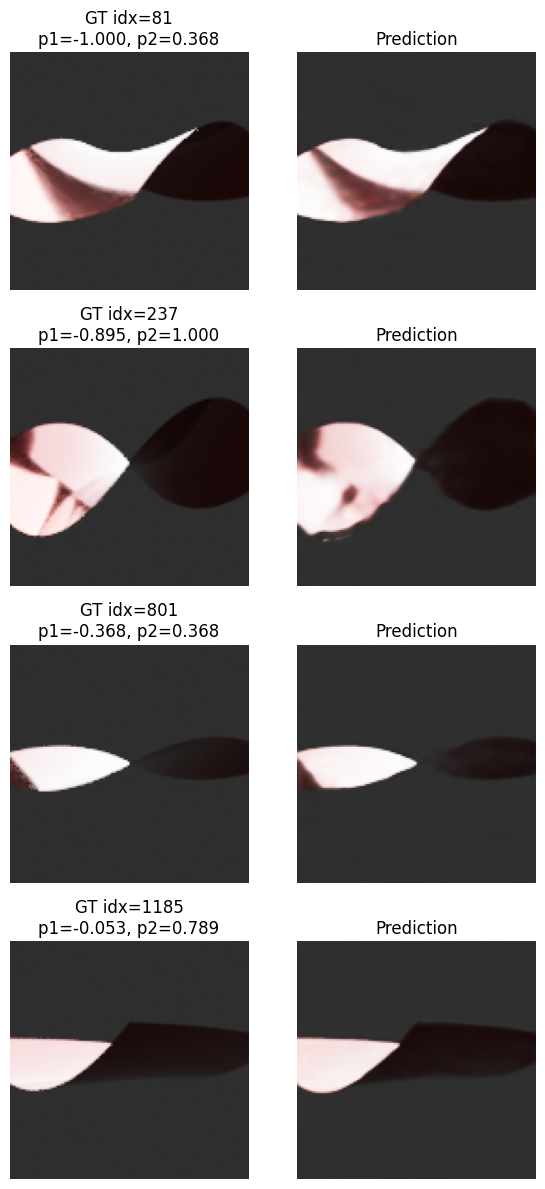

In [129]:
import random
import matplotlib.pyplot as plt
import torch

model.eval()
model.to(device)

# ---- choose the material you care about ----
target_metallic = 1.0
target_roughness = 0.1

# tolerance for float comparison
tol = 1e-6

# filter indices in the dataset that match this material
mask = (
    (abs(dataset.df["metallic"] - target_metallic) < tol) &
    (abs(dataset.df["roughness"] - target_roughness) < tol)
)

candidate_indices = list(dataset.df[mask].index)

print(f"Found {len(candidate_indices)} samples with metallic={target_metallic}, roughness={target_roughness}")

n_samples = min(4, len(candidate_indices))
indices = random.sample(candidate_indices, n_samples)

fig, axes = plt.subplots(n_samples, 2, figsize=(6, 3 * n_samples))
if n_samples == 1:
    axes = [axes]

for ax_row, idx in zip(axes, indices):
    # load sample
    param_vec, img_gt = dataset[idx]
    param_vec = param_vec.unsqueeze(0).to(device)
    img_gt_batch = img_gt.unsqueeze(0).to(device)

    with torch.no_grad():
        img_pred = model(param_vec)

    img_gt_np = img_gt_batch.squeeze(0).permute(1, 2, 0).cpu().numpy().clip(0, 1)
    img_pred_np = img_pred.squeeze(0).permute(1, 2, 0).cpu().numpy().clip(0, 1)

    p1_val = float(dataset.df.iloc[idx]["p1"])
    p2_val = float(dataset.df.iloc[idx]["p2"])
    print(p1_val)
    print(p2_val)

    ax_row[0].imshow(img_gt_np)
    ax_row[0].set_title(f"GT idx={idx}\np1={p1_val:.3f}, p2={p2_val:.3f}")
    ax_row[0].axis("off")

    ax_row[1].imshow(img_pred_np)
    ax_row[1].set_title("Prediction")
    ax_row[1].axis("off")

plt.tight_layout()
plt.show()

In [72]:
df = pd.read_csv(csv_path)
print(df.columns)

Index(['image_path', 'sample_id', 'coeff_path', 'mesh_path', 'hue', 'metallic',
       'roughness', 'specular', 'material_type', 'base_color_r',
       'base_color_g', 'base_color_b', 'phi', 'theta', 'radius', 'p1', 'p2'],
      dtype='str')


In [82]:
from pathlib import Path
import imageio.v2 as imageio
train_dataset = BentPlaneDataset(csv_path_train, img_size=(128, 128))
param_vec_example, img_example= dataset[0]
latent_dim = param_vec_example.shape[0]
print("latent_dim:", latent_dim)
loader_train = DataLoader(dataset_train, batch_size=16, shuffle=True, num_workers=2)

latent_dim: 4


In [130]:
import os
import numpy as np
import torch
from torchvision.utils import save_image

model.eval()
model.to(device)

out_dir = "preds_fixed_shape_var_materials"
os.makedirs(out_dir, exist_ok=True)

# --- choose one geometry ---
p1, p2 = -1, 0.368
tol = 1e-3

# --- choose a few materials ---
materials = [
    (0.0, 0.1),  # mid
    (0.0, 0.9),  # matte
    (1.0, 0.1),  # shiny
]

mean = train_dataset.param_mean
std  = train_dataset.param_std

param_vecs = []
names = []

df = dataset.df

for metallic, roughness in materials:
    mask = (
        (abs(df["p1"]        - p1)   < tol) &
        (abs(df["p2"]        - p2)   < tol) &
        (abs(df["metallic"]  - metallic)    < tol) &
        (abs(df["roughness"] - roughness)   < tol)
    )
    matches = df[mask]
    row = matches.iloc[0]
    img_path = row["image_path"]

    # --- load GT image using same transform as dataset ---
    img_pil = Image.open(img_path).convert("RGB")
    gt = dataset.transform(img_pil)  # [3,H,W] in [0,1]

    # --- build param vector (same logic as dataset) ---
    scalars_np = np.array(
        [p1, p2, metallic, roughness],
        dtype=np.float32
    )
    if dataset.normalize_params:
        scalars_np = (scalars_np - mean) / std

    param_vec = torch.from_numpy(scalars_np).unsqueeze(0).to(device)  # [1,4]

    # --- predict ---
    with torch.no_grad():
        pred = model(param_vec).squeeze(0).clamp(0, 1)  # [3,H,W]

    # --- side-by-side [GT | Pred] ---
    sbs = torch.cat([gt, pred], dim=2)  # concat along width

    fname = f"p1_{p1:.2f}_p2_{p2:.2f}_m{metallic:.2f}_r{roughness:.2f}_gt_pred.png"
    save_path = os.path.join(out_dir, fname)
    save_image(sbs, save_path)
    print("Saved", save_path)

Saved preds_fixed_shape_var_materials/p1_-1.00_p2_0.37_m0.00_r0.10_gt_pred.png
Saved preds_fixed_shape_var_materials/p1_-1.00_p2_0.37_m0.00_r0.90_gt_pred.png
Saved preds_fixed_shape_var_materials/p1_-1.00_p2_0.37_m1.00_r0.10_gt_pred.png


In [83]:
idx = 1341  # from your figure
row = dataset.df.iloc[idx]

print("RAW CSV row:")
print("idx", idx,
      "p1", row["p1"],
      "p2", row["p2"],
      "metallic", row["metallic"],
      "roughness", row["roughness"])

# Build param vector exactly as in BentPlaneDataset._build_param_vector
import numpy as np
scalars_np = np.array([
    float(row["p1"]),
    float(row["p2"]),
    float(row["metallic"]),
    float(row["roughness"]),
], dtype=np.float32)

# IMPORTANT: normalize with *training* stats, not OOD stats
mean = train_dataset.param_mean   # from the dataset you trained on
std  = train_dataset.param_std

scalars_np_norm = (scalars_np - mean) / std
param_vec = torch.from_numpy(scalars_np_norm).unsqueeze(0).to(device)

# Predict
model.eval()
with torch.no_grad():
    pred_from_row = model(param_vec)  # [1,3,H,W]

RAW CSV row:
idx 1341 p1 0.1578947368421053 p2 -0.6842105263157895 metallic 1.0 roughness 0.1


In [85]:
idx = 1341

# 1) Raw CSV row (you already printed this)
row = dataset.df.iloc[idx]
print("RAW CSV row:")
print("p1", row["p1"], "p2", row["p2"],
      "metallic", row["metallic"], "roughness", row["roughness"])

# 2) What ood_dataset is returning now
param_vec_ds, gt_img = dataset[idx]       # param_vec_ds: [4]
print("\nparam_vec from ood_dataset[idx]:")
print(param_vec_ds)
print("shape:", param_vec_ds.shape)

# 3) Manual param vec using *training* stats
import numpy as np
scalars_np = np.array([
    float(row["p1"]),
    float(row["p2"]),
    float(row["metallic"]),
    float(row["roughness"]),
], dtype=np.float32)

mean = train_dataset.param_mean   # from the dataset you trained with
std  = train_dataset.param_std

scalars_np_norm = (scalars_np - mean) / std
param_vec_manual = torch.from_numpy(scalars_np_norm)
print("\nparam_vec manual (using train stats):")
print(param_vec_manual)

print("\nabs difference:")
print((param_vec_ds - param_vec_manual).abs())

RAW CSV row:
p1 0.1578947368421053 p2 -0.6842105263157895 metallic 1.0 roughness 0.1

param_vec from ood_dataset[idx]:
tensor([ 0.9258, -1.1272,  1.0000, -1.2247])
shape: torch.Size([4])

param_vec manual (using train stats):
tensor([ 0.2474, -1.0720,  1.0000, -1.2247])

abs difference:
tensor([6.7844e-01, 5.5290e-02, 0.0000e+00, 9.6560e-06])


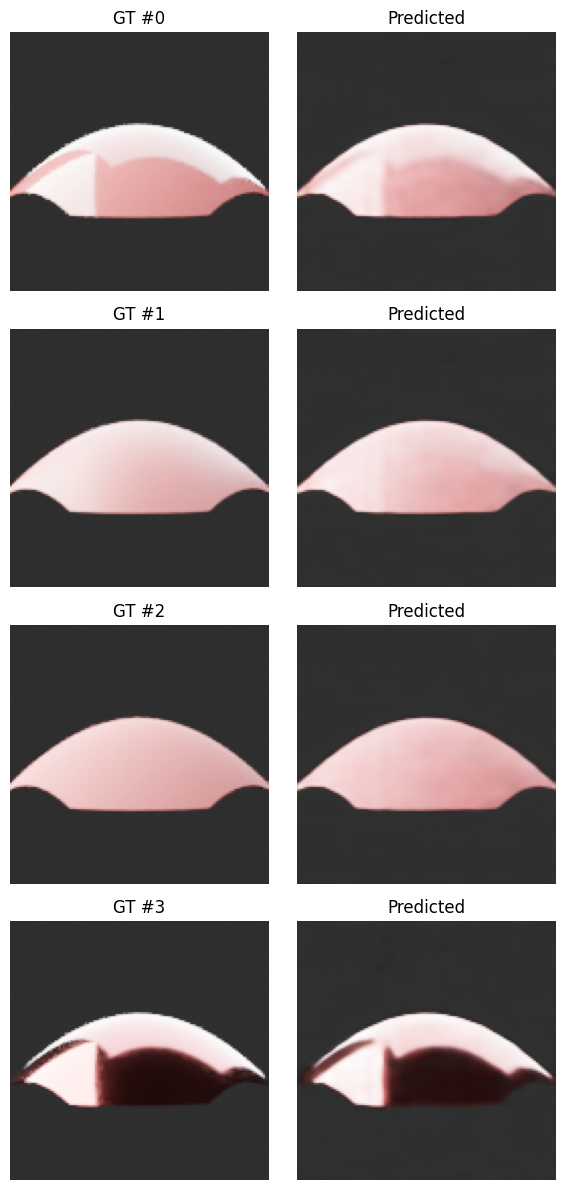

In [70]:
B = params.size(0)
fig, axes = plt.subplots(B, 2, figsize=(6, 3*B))

if B == 1:
    axes = [axes]  # make it indexable as axes[0][0], axes[0][1]

for i in range(B):
    pred_img = to_numpy_img(preds[i])
    gt_img   = to_numpy_img(gts[i])

    axes[i][0].imshow(gt_img)
    axes[i][0].set_title(f"GT #{idxs[i]}")
    axes[i][0].axis("off")

    axes[i][1].imshow(pred_img)
    axes[i][1].set_title("Predicted")
    axes[i][1].axis("off")

plt.tight_layout()
plt.savefig("output.png")
plt.show()


In [79]:
import torch
import imageio.v2 as imageio
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Load dataset to reuse normalization stats
dataset = BentPlaneDatasetWithEdges(
    "./plane_dataset_large/renders/metadata_images_all.csv",
    img_size=(128, 128)
)
param_mean = dataset.param_mean   # [4] for [p1,p2,metallic,roughness]
param_std  = dataset.param_std

# 2. Build grid from the same values you used to generate volumes
P1_MIN, P1_MAX = -1.0, 1.0
P2_MIN, P2_MAX = -1.0, 1.0
NUM_P1, NUM_P2 = 20, 20

p1_vals = np.linspace(P1_MIN, P1_MAX, NUM_P1)
p2_vals = np.linspace(P2_MIN, P2_MAX, NUM_P2)

traj = snake_traj(p2_vals, p1_vals)  # list of (p1,p2)

# 3. Fix material
metallic_val  = 1.0   # or 0.0 for plastic
roughness_val = 0.1  # pick one of your training roughnesses

# 4. Render video
output_dir = Path("./videos")
output_dir.mkdir(parents=True, exist_ok=True)
video_path = output_dir / "bent_plane_p1_p2_snake_40_metallic_0.1_edge_1.0_0.3.mp4"

model.to(device)
model.eval()

with imageio.get_writer(video_path, fps=24) as writer, torch.no_grad():
    for p2, p1 in traj:
        scalars_np = np.array(
            [p1, p2, metallic_val, roughness_val],
            dtype=np.float32
        )
        scalars_np = (scalars_np - param_mean) / param_std
        param_vec = torch.from_numpy(scalars_np).unsqueeze(0).to(device)  # [1,4]

        pred = model(param_vec)[0]  # [3,H,W]

        frame = (
            pred.clamp(0, 1)
                .mul(255)
                .byte()
                .cpu()
                .permute(1, 2, 0)
                .numpy()
        )
        writer.append_data(frame)
        #print(f"p1={p1:.3f}, p2={p2:.3f} -> frame")

print("Wrote", video_path)

Wrote videos/bent_plane_p1_p2_snake_40_metallic_0.1_edge_1.0_0.3.mp4


In [18]:
import numpy as np
import torch
import imageio.v2 as imageio
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csv_path = "./plane_dataset_large/renders/metadata_images_all.csv"
dataset = BentPlaneDataset(csv_path, img_size=(128, 128))
param_mean = dataset.param_mean    # shape [4] for [p1,p2,metallic,roughness]
param_std  = dataset.param_std

# 2. Load model and put it in eval mode
model.to(device)
model.eval()

# 3. Define material and p1/p2 path for the video
metallic_val  = 0.0   # or 0.0 for plastic
roughness_val = 0.1   # pick one of your training roughnesses

num_frames = 60
# e.g. move along a diagonal in (p1,p2) space
p_min, p_max = -1.0, 1.0
p1_values = np.linspace(p_min, p_max, num_frames)
p2_values = np.linspace(p_min, p_max, num_frames)

# 4. Render frames to video
output_dir = Path("./videos")
output_dir.mkdir(parents=True, exist_ok=True)
video_path = output_dir / "bent_plane_p1_p2_sweep_plastic_0.1.mp4"

fps = 24

with imageio.get_writer(video_path, fps=fps) as writer, torch.no_grad():
    for p1, p2 in zip(p1_values, p2_values):
        # build raw param vector [p1,p2,metallic,roughness]
        scalars_np = np.array(
            [p1, p2, metallic_val, roughness_val],
            dtype=np.float32
        )

        # normalize exactly like the dataset
        scalars_np = (scalars_np - param_mean) / param_std
        param_vec = torch.from_numpy(scalars_np).unsqueeze(0).to(device)  # [1,4]

        # predict image
        pred = model(param_vec)[0]  # [3,H,W], in [0,1]

        # convert to uint8 frame HxWx3
        frame = (
            pred.clamp(0, 1)
                .mul(255)
                .byte()
                .cpu()
                .permute(1, 2, 0)
                .numpy()
        )
        writer.append_data(frame)
        #print(f"p1={p1:.3f}, p2={p2:.3f} -> frame written")

print("Wrote video:", video_path)

Wrote video: videos/bent_plane_p1_p2_sweep_plastic_0.1.mp4
